In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation_final.csv')

In [3]:
df.shape

(3552, 18)

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sbtl caladium,sector 109,1.30,6915.0,3.0,2.0,3,16.0,Moderately Old,1701.0,0.0,0.0,0.0,0.0,0.0,1.0,134.0
1,flat,bestech park view sanskruti,sector 92,1.83,7871.0,4.0,3.0,3,8.0,New Property,2104.0,0.0,1.0,0.0,0.0,0.0,1.0,128.0
2,flat,gls arawali homes,sohna road,0.28,5983.0,2.0,2.0,2,3.0,Relatively New,520.0,0.0,0.0,0.0,0.0,0.0,1.0,42.0
3,flat,ats triumph,sector 104,2.60,8254.0,4.0,4.0,3+,12.0,Relatively New,2851.0,0.0,1.0,0.0,0.0,0.0,1.0,118.0
4,house,independent,sector 12,0.70,4118.0,4.0,4.0,1,2.0,Moderately Old,1700.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [5]:
latlong = pd.read_csv('latlong.csv')

In [6]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [7]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [8]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [9]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [10]:
new_df = df.merge(latlong, on='sector')

In [11]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'coordinates', 'latitude', 'longitude'],
      dtype='str')

In [12]:
group_df = new_df.groupby('sector').mean(numeric_only=True)[
    ['price','price_per_sqft','built_up_area','latitude','longitude']
]

In [13]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,2.968235,9502.647059,2916.529412,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 102,1.699429,10649.838095,1556.619048,28.4750,76.9715
sector 103,1.495000,7445.785714,1865.428571,28.4949,76.9845
...,...,...,...,...,...
sector 92,0.947576,5979.373737,1575.628081,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326
sector 95,0.466167,5140.466667,5806.033333,28.4172,76.9081


In [14]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

C:\Users\Aadi\AppData\Local\Temp\ipykernel_13100\860414701.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',


In [15]:
new_df.to_csv('data_viz1.csv',index=False)

In [16]:
df1 = pd.read_csv('gurgaon_properties.csv')

In [17]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,3 BHK Flat in Sector 109 Gurgaon,flat,sbtl caladium,1.30,6914.0,1880.0,Super Built up area 1880(174.66 sq.m.),3,2,3,NaN,"N/a, Sector 109 Gurgaon, Gurgaon, Haryana",16.0,East,5 to 10 Year Old,"['Palam Vihar Vyapar kendra', 'Chirag Hospital...",Sbtl caladium is one of the most popular desti...,NaN,"['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Environment5 out of 5', 'Lifestyle4 out of 5..."
1,4 BHK Flat in Sector 92 Gurgaon,flat,bestech park view sanskruti,1.83,7870.0,2325.0,Super Built up area 2325(216 sq.m.),4,3,3,servant room,"Sector 92 Gurgaon, Sector 92 Gurgaon, Gurgaon,...",8.0,East,0 to 1 Year Old,"['Sapphire 93 Mall', 'Dwarka Expressway', 'NH-...",4bhk is available for sale in bestech park vie...,"['6 AC', '1 Modular Kitchen', 'No Bed', 'No Ch...","['Centrally Air Conditioned', 'Security / Fire...","['Green Area5 out of 5', 'Construction5 out of..."
2,4 BHK Flat in Shankar Vihar,flat,dlf city,2.02,8080.0,2500.0,Super Built up area 2500(232.26 sq.m.),4,3,1,NaN,"Shankar Vihar, Gurgaon, Haryana",2.0,NaN,0 to 1 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Dr. ...",One of the best places to live in gurgaon. Has...,[],NaN,"['Environment4.5 out of 5', 'Lifestyle5 out of..."
3,3 BHK Flat in Sector 83 Gurgaon,flat,emaar palm gardens,1.55,9011.0,1720.0,Super Built up area 1720(159.79 sq.m.)Built Up...,3,3,3,servant room,"804, Sector 83 Gurgaon, Gurgaon, Haryana",4.0,West,1 to 5 Year Old,"[""V'Lante Mall"", 'NH 48 Gurugram', 'iGrow Mont...",Check out this 3 bhk apartment for sale in ema...,"['3 Wardrobe', '1 Exhaust Fan', '3 Geyser', '1...","['Centrally Air Conditioned', 'Water purifier'...","['Green Area5 out of 5', 'Construction4 out of..."
4,2 BHK Flat in Sohna,flat,gls arawali homes,0.28,5982.0,468.0,Carpet area: 468 (43.48 sq.m.),2,2,2,NaN,"T11-301, Sohna, Gurgaon, Haryana",3.0,NaN,1 to 5 Year Old,"['Huda City Centre', 'Golf Course Road', 'Delh...","Sun facing, moduler kitchen, newly constructed","['1 Wardrobe', '3 Fan', '3 Light', '2 Curtains...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Green Area5 out of 5', 'Amenities4 out of 5'..."


In [18]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [19]:
wordcloud_df.head()

,features,sector
0,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sector 109
1,"['Centrally Air Conditioned', 'Security / Fire...",sector 92
2,NaN,sohna road
3,"['Centrally Air Conditioned', 'Water purifier'...",sector 104
4,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 12


In [20]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [21]:
main

['Security / Fire Alarm',
 'Power Back-up',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'Water purifier',
 'High Ceiling Height',
 'Maintenance Staff',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Internet/wi-fi connectivity',
 'Airy Rooms',
 'Low Density Society',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Club house / Community Center',
 'Water softening plant',
 'Centrally Air Conditioned',
 'Security / Fire Alarm',
 'Power Back-up',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'Maintenance Staff',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Piped-gas',
 'Internet/wi-fi connectivity',
 'Recently Renovated',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Airy Rooms',
 'Waste Disposal',
 'Rain Water Harv

In [23]:
from wordcloud import WordCloud

In [24]:
feature_text = ' '.join(main)

In [25]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

In [26]:
feature_text

'Security / Fire Alarm Power Back-up Feng Shui / Vaastu Compliant Intercom Facility Lift(s) Water purifier High Ceiling Height Maintenance Staff Water Storage Separate entry for servant room No open drainage around Visitor Parking Swimming Pool Park Security Personnel Natural Light Internet/wi-fi connectivity Airy Rooms Low Density Society Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Community Center Water softening plant Centrally Air Conditioned Security / Fire Alarm Power Back-up Feng Shui / Vaastu Compliant Intercom Facility Lift(s) Maintenance Staff Water Storage Separate entry for servant room No open drainage around Piped-gas Internet/wi-fi connectivity Recently Renovated Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Waste Disposal Rain Water Harvesting Water softening plant Shopping Centre Fitness Centre / GYM Club house / Community Center Centrally Air Conditioned Water purifier Security / Fire Alarm Feng Shui / Vaastu

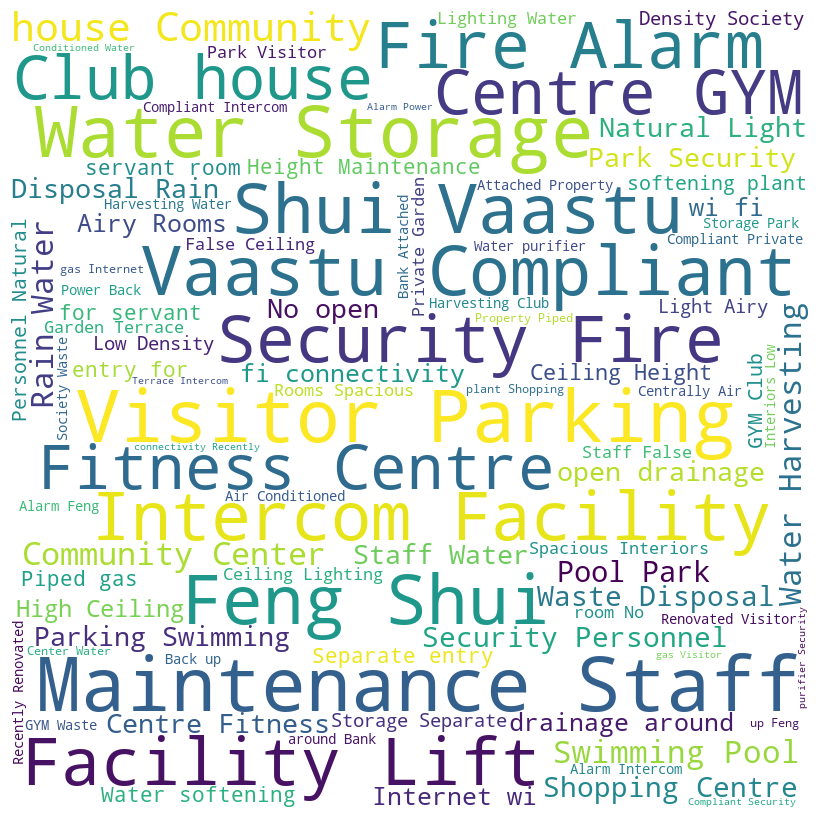

In [27]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

In [28]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names='property_type',
    values='price_per_sqft',
    parents='bedRoom',
    title="Sample Sunburst Chart"
)
fig.show()

In [29]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [30]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [31]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()


C:\Users\Aadi\AppData\Local\Temp\ipykernel_13100\3761596323.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['property_type'] == 'house']['price'])
C:\Users\Aadi\AppData\Local\Temp\ipykernel_13100\3761596323.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['property_type'] == '

<Axes: xlabel='price', ylabel='Density'>

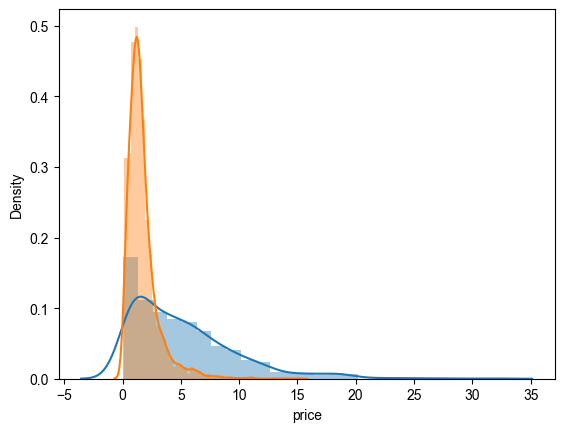

In [32]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])

In [33]:
new_df['sector'].unique().tolist().insert(0,'overall')